O período dos dados vai de 2023-01-01 00:00:00 até 2024-12-31 00:00:00


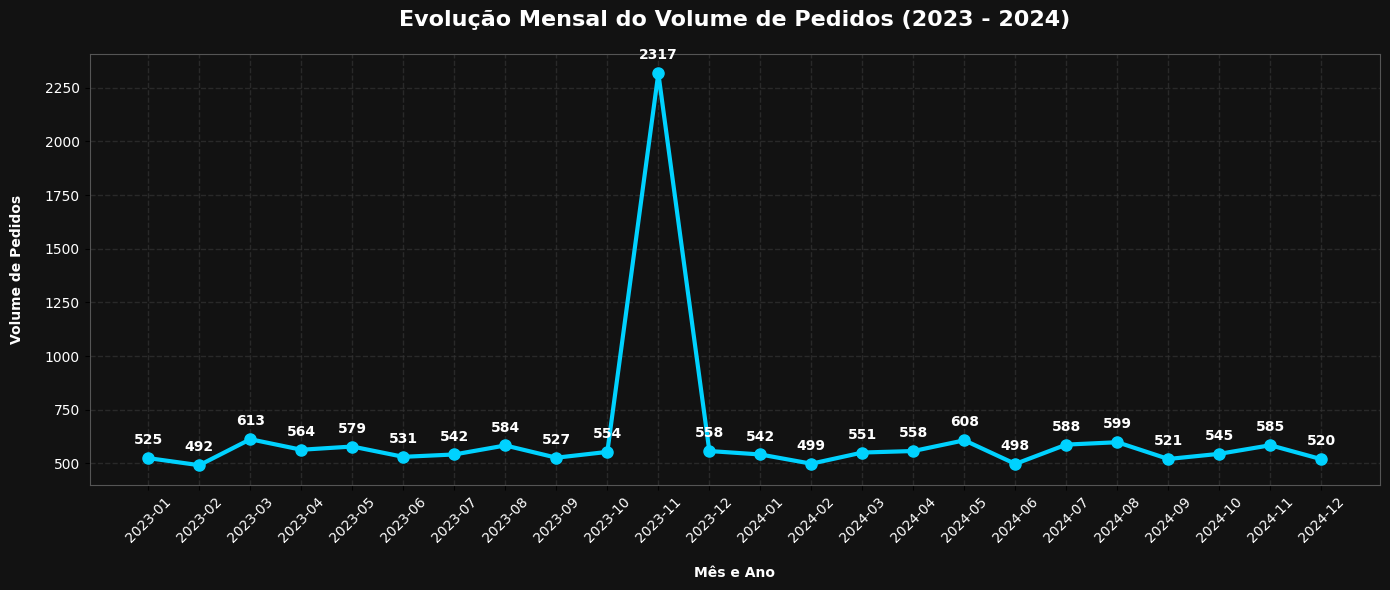

In [ ]:
# 4) Analise a evolução mensal do volume de pedidos ao longo de 2023 e 2024. Há sazonalidade? Identifique picos e quedas e formule uma hipótese para cada padrão encontrado.

import pandas as pd
import matplotlib.pyplot as plt

df_pedidos = pd.read_csv('../data/pedidos.csv')

NOME_COLUNA_DATA = 'data_pedido' 
df_pedidos[NOME_COLUNA_DATA] = pd.to_datetime(df_pedidos[NOME_COLUNA_DATA])

df_pedidos = df_pedidos[(df_pedidos[NOME_COLUNA_DATA].dt.year >= 2023) & (df_pedidos[NOME_COLUNA_DATA].dt.year <= 2024)]

df_pedidos['ano_mes'] = df_pedidos[NOME_COLUNA_DATA].dt.to_period('M')
evolucao_mensal = df_pedidos.groupby('ano_mes').size()

COR_FUNDO = '#121212'
fig = plt.figure(figsize=(14, 6), facecolor=COR_FUNDO)
ax = plt.axes()
ax.set_facecolor(COR_FUNDO)

x_labels = evolucao_mensal.index.astype(str)

plt.plot(x_labels, evolucao_mensal.values, color='#00D2FF', marker='o', linewidth=3, markersize=8)

plt.title('Evolução Mensal do Volume de Pedidos (2023 - 2024)', fontsize=16, fontweight='bold', color='white', pad=20)
plt.xlabel('Mês e Ano', color='white', fontweight='bold', labelpad=15)
plt.ylabel('Volume de Pedidos', color='white', fontweight='bold', labelpad=15)

plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

ax.grid(color='#333333', linestyle='--', linewidth=1, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('#555555')

for i, valor in enumerate(evolucao_mensal.values):
    ax.annotate(f'{valor}', (x_labels[i], valor), textcoords="offset points", xytext=(0,10), ha='center', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()